In [ ]:
zip_path = "/content/drive/MyDrive/Colab Notebooks/OCTDL.zip"     # <-- update if needed
extract_dir = "/content/drive/MyDrive/Colab Notebooks/OCTDL"      # destination folder


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd '/content/drive/MyDrive/Colab Notebooks/'

/content/drive/MyDrive/Colab Notebooks


In [ ]:
pwd

'/content/drive/MyDrive/Colab Notebooks'

In [ ]:
ls

'Cancer Project.ipynb'   class_to_idx.json    OCTDL_proj.ipynb
 checkpoints_sanity/     class_weights.json   OCTDL.zip
 Classroom/              OCTDL/


In [ ]:
!unzip -q "$zip_path" -d "$extract_dir"


replace /content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL/AMD/amd_1047099_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import os

root = "/content/drive/MyDrive/Colab Notebooks/OCTDL"    # update if your extract dir is different
print("Folders inside OCTDL:", os.listdir(root))


Folders inside OCTDL: ['OCTDL_labels.csv', 'OCTDL', 'checkpoints_sanity']


In [ ]:
import os
import shutil

# Define the paths
root_dir = "/content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL"
nested_dir = os.path.join(root_dir, "OCTDL")

if os.path.exists(nested_dir):
    # Move contents from nested_dir to root_dir
    for item in os.listdir(nested_dir):
        s = os.path.join(nested_dir, item)
        d = os.path.join(root_dir, item)
        if os.path.isdir(s):
            shutil.move(s, d)
        else:
            shutil.move(s, d)

    # Remove the now empty nested_dir
    shutil.rmtree(nested_dir)
    print(f"Flattened directory structure: moved contents from '{nested_dir}' to '{root_dir}' and removed '{nested_dir}'")
else:
    print(f"No nested directory '{nested_dir}' found to flatten.")

print("Current folders inside OCTDL:", os.listdir(root_dir))

No nested directory '/content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL/OCTDL' found to flatten.
Current folders inside OCTDL: ['AMD', 'DME', 'ERM', 'NO', 'RAO', 'RVO', 'VID', 'checkpoints_sanity']


In [ ]:
import os

root = "/content/drive/MyDrive/Colab Notebooks/OCTDL"    # update if your extract dir is different
print("Folders inside OCTDL:", os.listdir(root))

Folders inside OCTDL: ['OCTDL_labels.csv', 'OCTDL', 'checkpoints_sanity']


In [ ]:
# === OCTDL: Optimized Dataset + Dataloader Setup (single cell) ===
# - Place this cell near the top of your notebook (after unzip step).
# - Edit ROOT if your dataset path differs.
# - Designed for Colab T4: BATCH_SIZE/NUM_WORKERS tuned, persistent_workers=True for speed.

import os, json, time, random
from pathlib import Path
from collections import Counter
import torch
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image

# --------------------- CONFIG ---------------------
ROOT = "/content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL"           # <- update if your folder is in a different place
IMG_SIZE = 224
BATCH_SIZE = 32                    # target per-GPU batch for ViT/DeiT; lower for MaxViT if OOM
NUM_WORKERS = 4                    # Colab T4 sweet spot: 2-4
PIN_MEMORY = True
PERSISTENT_WORKERS = True
VAL_SPLIT = 0.20                   # stratified val split fraction
RANDOM_SEED = 42
CLASS_MAP_JSON = "/content/class_to_idx.json"
THROUGHPUT_BATCHES = 20            # number of batches to sample for a quick throughput test

# Repro
torch.manual_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# --------------------- Sanity: dataset root & classes ---------------------
root_path = Path(ROOT)
assert root_path.exists(), f"Dataset root not found at {ROOT}. Update ROOT and re-run."

classes = [p.name for p in sorted(root_path.iterdir()) if p.is_dir()]
assert len(classes) > 0, "No class folders found — ensure dataset follows ImageFolder layout."
print("Detected classes (sorted):", classes)

# --------------------- Gather samples and per-class counts ---------------------
IMG_EXTS = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")
class_to_idx = {cls: i for i, cls in enumerate(classes)}
all_samples = []
counts = Counter()

for cls in classes:
    cls_dir = root_path / cls
    files = [p for p in sorted(cls_dir.iterdir()) if p.suffix.lower() in IMG_EXTS]
    counts[cls] = len(files)
    for p in files:
        all_samples.append((str(p), class_to_idx[cls]))

total_images = len(all_samples)
print(f"Total images detected: {total_images}")
print("Per-class counts:")
for k,v in counts.items():
    print(f"  {k}: {v}")

# Save class map (ensures reproducible label ordering)
with open(CLASS_MAP_JSON, "w") as f:
    json.dump(class_to_idx, f, indent=2)
print(f"Saved class->index mapping to: {CLASS_MAP_JSON}")

# --------------------- Stratified split (no sklearn dependency) ---------------------
random.shuffle(all_samples)  # shuffle globally first
train_items, val_items = [], []
per_class_files = {}
for p, label in all_samples:
    per_class_files.setdefault(label, []).append(p)

for label, files in per_class_files.items():
    random.shuffle(files)
    n_val = max(1, int(len(files) * VAL_SPLIT))
    val_files = files[:n_val]
    train_files = files[n_val:]
    # ensure at least one train item per class if very small:
    if len(train_files) == 0 and len(val_files) > 1:
        train_files.append(val_files.pop())
    train_items += [(p, label) for p in train_files]
    val_items   += [(p, label) for p in val_files]

print(f"Train samples: {len(train_items)}  |  Val samples: {len(val_items)}")

# --------------------- Transforms ---------------------
# Use ImageNet normalization for timm pretrained backbones
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    # convert grayscale to RGB if needed; if already RGB this is no-op
    transforms.Lambda(lambda img: img.convert("RGB") if img.mode != "RGB" else img),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.08, contrast=0.08),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_tf = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB") if img.mode != "RGB" else img),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# --------------------- Dataset wrapper from (path,label) pairs ---------------------
class PathListDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform
    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        p, label = self.items[idx]
        img = Image.open(p)
        # For safety, convert to RGB here so transforms get consistent PIL mode
        if img.mode != "RGB":
            img = img.convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

train_ds = PathListDataset(train_items, transform=train_tf)
val_ds   = PathListDataset(val_items, transform=val_tf)

# --------------------- DataLoaders ---------------------
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS, prefetch_factor=2
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=max(1, NUM_WORKERS//2), pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS, prefetch_factor=2
)

# --------------------- Quick sanity checks ---------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# one-batch shape check
try:
    imgs, labels = next(iter(train_loader))
    print("One batch imgs.shape:", imgs.shape, "  labels.shape:", labels.shape)
    assert imgs.ndim == 4 and imgs.shape[1] == 3, "Expected [B,3,H,W] tensors"
    print("Label distribution in this batch:", dict(Counter(labels.tolist())))
except Exception as e:
    print("ERROR while fetching batch (check transforms / disk read):", e)

# throughput test (data + transforms only) over a few batches
print("\nRunning a quick throughput test (data + transforms)...")
start = time.time()
n = 0
for i, (x, y) in enumerate(train_loader):
    n += x.size(0)
    if i+1 >= THROUGHPUT_BATCHES:
        break
elapsed = time.time() - start
print(f"Loaded {n} images in {elapsed:.2f}s -> {n/elapsed:.2f} samples/sec (approx)")

# print sample entries and class map
print("\nSample train items (5):")
for p,l in train_items[:5]:
    print(" ", p, "->", [k for k,v in class_to_idx.items() if v==l][0])

print("\nclass_to_idx mapping saved to:", CLASS_MAP_JSON)
with open(CLASS_MAP_JSON, "w") as f:
    json.dump(class_to_idx, f, indent=2)

print("\nDataloaders ready — proceed to model creation & training loop.")


Detected classes (sorted): ['AMD', 'DME', 'ERM', 'NO', 'RAO', 'RVO', 'VID', 'checkpoints_sanity']
Total images detected: 2064
Per-class counts:
  AMD: 1231
  DME: 147
  ERM: 155
  NO: 332
  RAO: 22
  RVO: 101
  VID: 76
  checkpoints_sanity: 0
Saved class->index mapping to: /content/class_to_idx.json
Train samples: 1653  |  Val samples: 411
Device: cuda


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


One batch imgs.shape: torch.Size([32, 3, 224, 224])   labels.shape: torch.Size([32])
Label distribution in this batch: {0: 13, 1: 4, 5: 5, 6: 6, 3: 3, 4: 1}

Running a quick throughput test (data + transforms)...
Loaded 640 images in 78.84s -> 8.12 samples/sec (approx)

Sample train items (5):
  /content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL/AMD/amd_3595373_2.jpg -> AMD
  /content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL/AMD/amd_7992984_2.jpg -> AMD
  /content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL/AMD/amd_8214789_1.jpg -> AMD
  /content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL/AMD/amd_8200284_1.jpg -> AMD
  /content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL/AMD/amd_6094846_2.jpg -> AMD

class_to_idx mapping saved to: /content/class_to_idx.json

Dataloaders ready — proceed to model creation & training loop.


In [ ]:
# === OCTDL: Optimized Dataset + Dataloader Setup (single cell) ===
# - Place this cell near the top of your notebook (after unzip step).
# - Edit ROOT if your dataset path differs.
# - Designed for Colab T4: BATCH_SIZE/NUM_WORKERS tuned, persistent_workers=True for speed.

import os, json, time, random
from pathlib import Path
from collections import Counter
import torch
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image

# --------------------- CONFIG ---------------------
ROOT = "/content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL"            # <- update if your folder is in a different place
IMG_SIZE = 224
BATCH_SIZE = 32                    # target per-GPU batch for ViT/DeiT; lower for MaxViT if OOM
NUM_WORKERS = 4                    # Colab T4 sweet spot: 2-4
PIN_MEMORY = True
PERSISTENT_WORKERS = True
VAL_SPLIT = 0.20                   # stratified val split fraction
RANDOM_SEED = 42
CLASS_MAP_JSON = "/content/class_to_idx.json"
THROUGHPUT_BATCHES = 20            # number of batches to sample for a quick throughput test

# Repro
torch.manual_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# --------------------- Sanity: dataset root & classes ---------------------
root_path = Path(ROOT)
assert root_path.exists(), f"Dataset root not found at {ROOT}. Update ROOT and re-run."

classes = [p.name for p in sorted(root_path.iterdir()) if p.is_dir()]
assert len(classes) > 0, "No class folders found — ensure dataset follows ImageFolder layout."
print("Detected classes (sorted):", classes)

# --------------------- Gather samples and per-class counts ---------------------
IMG_EXTS = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")
class_to_idx = {cls: i for i, cls in enumerate(classes)}
all_samples = []
counts = Counter()

for cls in classes:
    cls_dir = root_path / cls
    files = [p for p in sorted(cls_dir.iterdir()) if p.suffix.lower() in IMG_EXTS]
    counts[cls] = len(files)
    for p in files:
        all_samples.append((str(p), class_to_idx[cls]))

total_images = len(all_samples)
print(f"Total images detected: {total_images}")
print("Per-class counts:")
for k,v in counts.items():
    print(f"  {k}: {v}")

# Save class map (ensures reproducible label ordering)
with open(CLASS_MAP_JSON, "w") as f:
    json.dump(class_to_idx, f, indent=2)
print(f"Saved class->index mapping to: {CLASS_MAP_JSON}")

# --------------------- Stratified split (no sklearn dependency) ---------------------
random.shuffle(all_samples)  # shuffle globally first
train_items, val_items = [], []
per_class_files = {}
for p, label in all_samples:
    per_class_files.setdefault(label, []).append(p)

for label, files in per_class_files.items():
    random.shuffle(files)
    n_val = max(1, int(len(files) * VAL_SPLIT))
    val_files = files[:n_val]
    train_files = files[n_val:]
    # ensure at least one train item per class if very small:
    if len(train_files) == 0 and len(val_files) > 1:
        train_files.append(val_files.pop())
    train_items += [(p, label) for p in train_files]
    val_items   += [(p, label) for p in val_files]

print(f"Train samples: {len(train_items)}  |  Val samples: {len(val_items)}")

# --------------------- Transforms ---------------------
# Use ImageNet normalization for timm pretrained backbones
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    # convert grayscale to RGB if needed; if already RGB this is no-op
    transforms.Lambda(lambda img: img.convert("RGB") if img.mode != "RGB" else img),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.08, contrast=0.08),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_tf = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB") if img.mode != "RGB" else img),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# --------------------- Dataset wrapper from (path,label) pairs ---------------------
class PathListDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform
    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        p, label = self.items[idx]
        img = Image.open(p)
        # For safety, convert to RGB here so transforms get consistent PIL mode
        if img.mode != "RGB":
            img = img.convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

train_ds = PathListDataset(train_items, transform=train_tf)
val_ds   = PathListDataset(val_items, transform=val_tf)

# --------------------- DataLoaders ---------------------
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS, prefetch_factor=2
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=max(1, NUM_WORKERS//2), pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS, prefetch_factor=2
)

# --------------------- Quick sanity checks ---------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# one-batch shape check
try:
    imgs, labels = next(iter(train_loader))
    print("One batch imgs.shape:", imgs.shape, "  labels.shape:", labels.shape)
    assert imgs.ndim == 4 and imgs.shape[1] == 3, "Expected [B,3,H,W] tensors"
    print("Label distribution in this batch:", dict(Counter(labels.tolist())))
except Exception as e:
    print("ERROR while fetching batch (check transforms / disk read):", e)

# throughput test (data + transforms only) over a few batches
print("\nRunning a quick throughput test (data + transforms)...")
start = time.time()
n = 0
for i, (x, y) in enumerate(train_loader):
    n += x.size(0)
    if i+1 >= THROUGHPUT_BATCHES:
        break
elapsed = time.time() - start
print(f"Loaded {n} images in {elapsed:.2f}s -> {n/elapsed:.2f} samples/sec (approx)")

# print sample entries and class map
print("\nSample train items (5):")
for p,l in train_items[:5]:
    print(" ", p, "->", [k for k,v in class_to_idx.items() if v==l][0])

print("\nclass_to_idx mapping saved to:", CLASS_MAP_JSON)
with open(CLASS_MAP_JSON, "w") as f:
    json.dump(class_to_idx, f, indent=2)

print("\nDataloaders ready — proceed to model creation & training loop.")


Detected classes (sorted): ['AMD', 'DME', 'ERM', 'NO', 'RAO', 'RVO', 'VID', 'checkpoints_sanity']
Total images detected: 2064
Per-class counts:
  AMD: 1231
  DME: 147
  ERM: 155
  NO: 332
  RAO: 22
  RVO: 101
  VID: 76
  checkpoints_sanity: 0
Saved class->index mapping to: /content/class_to_idx.json
Train samples: 1653  |  Val samples: 411
Device: cuda
One batch imgs.shape: torch.Size([32, 3, 224, 224])   labels.shape: torch.Size([32])
Label distribution in this batch: {0: 13, 1: 4, 5: 5, 6: 6, 3: 3, 4: 1}

Running a quick throughput test (data + transforms)...
Loaded 640 images in 7.82s -> 81.84 samples/sec (approx)

Sample train items (5):
  /content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL/AMD/amd_3595373_2.jpg -> AMD
  /content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL/AMD/amd_7992984_2.jpg -> AMD
  /content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL/AMD/amd_8214789_1.jpg -> AMD
  /content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL/AMD/amd_8200284_1.jpg -> AM

In [ ]:
# === OCTDL: Optimized Dataset + Dataloader Setup (single cell) ===
# - Place this cell near the top of your notebook (after unzip step).
# - Edit ROOT if your dataset path differs.
# - Designed for Colab T4: BATCH_SIZE/NUM_WORKERS tuned, persistent_workers=True for speed.

import os, json, time, random
from pathlib import Path
from collections import Counter
import torch
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image

# --------------------- CONFIG ---------------------
ROOT = "/content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL"            # <- update if your folder is in a different place
IMG_SIZE = 224
BATCH_SIZE = 32                    # target per-GPU batch for ViT/DeiT; lower for MaxViT if OOM
NUM_WORKERS = 4                    # Colab T4 sweet spot: 2-4
PIN_MEMORY = True
PERSISTENT_WORKERS = True
VAL_SPLIT = 0.20                   # stratified val split fraction
RANDOM_SEED = 42
CLASS_MAP_JSON = "/content/drive/MyDrive/Colab Notebooks/class_to_idx.json"
THROUGHPUT_BATCHES = 20            # number of batches to sample for a quick throughput test

# Repro
torch.manual_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# --------------------- Sanity: dataset root & classes ---------------------
root_path = Path(ROOT)
assert root_path.exists(), f"Dataset root not found at {ROOT}. Update ROOT and re-run."

classes = [p.name for p in sorted(root_path.iterdir()) if p.is_dir()]
assert len(classes) > 0, "No class folders found — ensure dataset follows ImageFolder layout."
print("Detected classes (sorted):", classes)

# --------------------- Gather samples and per-class counts ---------------------
IMG_EXTS = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")
class_to_idx = {cls: i for i, cls in enumerate(classes)}
all_samples = []
counts = Counter()

for cls in classes:
    cls_dir = root_path / cls
    files = [p for p in sorted(cls_dir.iterdir()) if p.suffix.lower() in IMG_EXTS]
    counts[cls] = len(files)
    for p in files:
        all_samples.append((str(p), class_to_idx[cls]))

total_images = len(all_samples)
print(f"Total images detected: {total_images}")
print("Per-class counts:")
for k,v in counts.items():
    print(f"  {k}: {v}")

# Save class map (ensures reproducible label ordering)
with open(CLASS_MAP_JSON, "w") as f:
    json.dump(class_to_idx, f, indent=2)
print(f"Saved class->index mapping to: {CLASS_MAP_JSON}")

# --------------------- Stratified split (no sklearn dependency) ---------------------
random.shuffle(all_samples)  # shuffle globally first
train_items, val_items = [], []
per_class_files = {}
for p, label in all_samples:
    per_class_files.setdefault(label, []).append(p)

for label, files in per_class_files.items():
    random.shuffle(files)
    n_val = max(1, int(len(files) * VAL_SPLIT))
    val_files = files[:n_val]
    train_files = files[n_val:]
    # ensure at least one train item per class if very small:
    if len(train_files) == 0 and len(val_files) > 1:
        train_files.append(val_files.pop())
    train_items += [(p, label) for p in train_files]
    val_items   += [(p, label) for p in val_files]

print(f"Train samples: {len(train_items)}  |  Val samples: {len(val_items)}")

# --------------------- Transforms ---------------------
# Use ImageNet normalization for timm pretrained backbones
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    # convert grayscale to RGB if needed; if already RGB this is no-op
    transforms.Lambda(lambda img: img.convert("RGB") if img.mode != "RGB" else img),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.08, contrast=0.08),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_tf = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB") if img.mode != "RGB" else img),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# --------------------- Dataset wrapper from (path,label) pairs ---------------------
class PathListDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform
    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        p, label = self.items[idx]
        img = Image.open(p)
        # For safety, convert to RGB here so transforms get consistent PIL mode
        if img.mode != "RGB":
            img = img.convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

train_ds = PathListDataset(train_items, transform=train_tf)
val_ds   = PathListDataset(val_items, transform=val_tf)

# --------------------- DataLoaders ---------------------
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS, prefetch_factor=2
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=max(1, NUM_WORKERS//2), pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS, prefetch_factor=2
)

# --------------------- Quick sanity checks ---------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# one-batch shape check
try:
    imgs, labels = next(iter(train_loader))
    print("One batch imgs.shape:", imgs.shape, "  labels.shape:", labels.shape)
    assert imgs.ndim == 4 and imgs.shape[1] == 3, "Expected [B,3,H,W] tensors"
    print("Label distribution in this batch:", dict(Counter(labels.tolist())))
except Exception as e:
    print("ERROR while fetching batch (check transforms / disk read):", e)

# throughput test (data + transforms only) over a few batches
print("\nRunning a quick throughput test (data + transforms)...")
start = time.time()
n = 0
for i, (x, y) in enumerate(train_loader):
    n += x.size(0)
    if i+1 >= THROUGHPUT_BATCHES:
        break
elapsed = time.time() - start
print(f"Loaded {n} images in {elapsed:.2f}s -> {n/elapsed:.2f} samples/sec (approx)")

# print sample entries and class map
print("\nSample train items (5):")
for p,l in train_items[:5]:
    print(" ", p, "->", [k for k,v in class_to_idx.items() if v==l][0])

print("\nclass_to_idx mapping saved to:", CLASS_MAP_JSON)
with open(CLASS_MAP_JSON, "w") as f:
    json.dump(class_to_idx, f, indent=2)

print("\nDataloaders ready — proceed to model creation & training loop.")


Detected classes (sorted): ['AMD', 'DME', 'ERM', 'NO', 'RAO', 'RVO', 'VID', 'checkpoints_sanity']
Total images detected: 2064
Per-class counts:
  AMD: 1231
  DME: 147
  ERM: 155
  NO: 332
  RAO: 22
  RVO: 101
  VID: 76
  checkpoints_sanity: 0
Saved class->index mapping to: /content/drive/MyDrive/Colab Notebooks/class_to_idx.json
Train samples: 1653  |  Val samples: 411
Device: cuda
One batch imgs.shape: torch.Size([32, 3, 224, 224])   labels.shape: torch.Size([32])
Label distribution in this batch: {0: 13, 1: 4, 5: 5, 6: 6, 3: 3, 4: 1}

Running a quick throughput test (data + transforms)...
Loaded 640 images in 9.68s -> 66.12 samples/sec (approx)

Sample train items (5):
  /content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL/AMD/amd_3595373_2.jpg -> AMD
  /content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL/AMD/amd_7992984_2.jpg -> AMD
  /content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL/AMD/amd_8214789_1.jpg -> AMD
  /content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCT

In [ ]:
# === OCTDL: Optimized Dataset + Dataloader Setup (single cell) ===
# - Place this cell near the top of your notebook (after unzip step).
# - Edit ROOT if your dataset path differs.
# - Designed for Colab T4: BATCH_SIZE/NUM_WORKERS tuned, persistent_workers=True for speed.

import os, json, time, random
from pathlib import Path
from collections import Counter
import torch
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image

# --------------------- CONFIG ---------------------
ROOT = "/content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL"            # <- update if your folder is in a different place
IMG_SIZE = 224
BATCH_SIZE = 32                    # target per-GPU batch for ViT/DeiT; lower for MaxViT if OOM
NUM_WORKERS = 4                    # Colab T4 sweet spot: 2-4
PIN_MEMORY = True
PERSISTENT_WORKERS = True
VAL_SPLIT = 0.20                   # stratified val split fraction
RANDOM_SEED = 42
CLASS_MAP_JSON = "/content/drive/MyDrive/Colab Notebooks/class_to_idx.json"
THROUGHPUT_BATCHES = 20            # number of batches to sample for a quick throughput test

# Repro
torch.manual_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# --------------------- Sanity: dataset root & classes ---------------------
root_path = Path(ROOT)
assert root_path.exists(), f"Dataset root not found at {ROOT}. Update ROOT and re-run."

classes = [p.name for p in sorted(root_path.iterdir()) if p.is_dir()]
assert len(classes) > 0, "No class folders found — ensure dataset follows ImageFolder layout."
print("Detected classes (sorted):", classes)

# --------------------- Gather samples and per-class counts ---------------------
IMG_EXTS = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")
class_to_idx = {cls: i for i, cls in enumerate(classes)}
all_samples = []
counts = Counter()

for cls in classes:
    cls_dir = root_path / cls
    files = [p for p in sorted(cls_dir.iterdir()) if p.suffix.lower() in IMG_EXTS]
    counts[cls] = len(files)
    for p in files:
        all_samples.append((str(p), class_to_idx[cls]))

total_images = len(all_samples)
print(f"Total images detected: {total_images}")
print("Per-class counts:")
for k,v in counts.items():
    print(f"  {k}: {v}")

# Save class map (ensures reproducible label ordering)
with open(CLASS_MAP_JSON, "w") as f:
    json.dump(class_to_idx, f, indent=2)
print(f"Saved class->index mapping to: {CLASS_MAP_JSON}")

# --------------------- Stratified split (no sklearn dependency) ---------------------
random.shuffle(all_samples)  # shuffle globally first
train_items, val_items = [], []
per_class_files = {}
for p, label in all_samples:
    per_class_files.setdefault(label, []).append(p)

for label, files in per_class_files.items():
    random.shuffle(files)
    n_val = max(1, int(len(files) * VAL_SPLIT))
    val_files = files[:n_val]
    train_files = files[n_val:]
    # ensure at least one train item per class if very small:
    if len(train_files) == 0 and len(val_files) > 1:
        train_files.append(val_files.pop())
    train_items += [(p, label) for p in train_files]
    val_items   += [(p, label) for p in val_files]

print(f"Train samples: {len(train_items)}  |  Val samples: {len(val_items)}")

# --------------------- Transforms ---------------------
# Use ImageNet normalization for timm pretrained backbones
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    # convert grayscale to RGB if needed; if already RGB this is no-op
    transforms.Lambda(lambda img: img.convert("RGB") if img.mode != "RGB" else img),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.08, contrast=0.08),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_tf = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB") if img.mode != "RGB" else img),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# --------------------- Dataset wrapper from (path,label) pairs ---------------------
class PathListDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform
    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        p, label = self.items[idx]
        img = Image.open(p)
        # For safety, convert to RGB here so transforms get consistent PIL mode
        if img.mode != "RGB":
            img = img.convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

train_ds = PathListDataset(train_items, transform=train_tf)
val_ds   = PathListDataset(val_items, transform=val_tf)

# --------------------- DataLoaders ---------------------
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS, prefetch_factor=2
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=max(1, NUM_WORKERS//2), pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS, prefetch_factor=2
)

# --------------------- Quick sanity checks ---------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# one-batch shape check
try:
    imgs, labels = next(iter(train_loader))
    print("One batch imgs.shape:", imgs.shape, "  labels.shape:", labels.shape)
    assert imgs.ndim == 4 and imgs.shape[1] == 3, "Expected [B,3,H,W] tensors"
    print("Label distribution in this batch:", dict(Counter(labels.tolist())))
except Exception as e:
    print("ERROR while fetching batch (check transforms / disk read):", e)

# throughput test (data + transforms only) over a few batches
print("\nRunning a quick throughput test (data + transforms)...")
start = time.time()
n = 0
for i, (x, y) in enumerate(train_loader):
    n += x.size(0)
    if i+1 >= THROUGHPUT_BATCHES:
        break
elapsed = time.time() - start
print(f"Loaded {n} images in {elapsed:.2f}s -> {n/elapsed:.2f} samples/sec (approx)")

# print sample entries and class map
print("\nSample train items (5):")
for p,l in train_items[:5]:
    print(" ", p, "->", [k for k,v in class_to_idx.items() if v==l][0])

print("\nclass_to_idx mapping saved to:", CLASS_MAP_JSON)
with open(CLASS_MAP_JSON, "w") as f:
    json.dump(class_to_idx, f, indent=2)

print("\nDataloaders ready — proceed to model creation & training loop.")


Detected classes (sorted): ['AMD', 'DME', 'ERM', 'NO', 'RAO', 'RVO', 'VID', 'checkpoints_sanity']
Total images detected: 2064
Per-class counts:
  AMD: 1231
  DME: 147
  ERM: 155
  NO: 332
  RAO: 22
  RVO: 101
  VID: 76
  checkpoints_sanity: 0
Saved class->index mapping to: /content/drive/MyDrive/Colab Notebooks/class_to_idx.json
Train samples: 1653  |  Val samples: 411
Device: cuda
One batch imgs.shape: torch.Size([32, 3, 224, 224])   labels.shape: torch.Size([32])
Label distribution in this batch: {0: 13, 1: 4, 5: 5, 6: 6, 3: 3, 4: 1}

Running a quick throughput test (data + transforms)...
Loaded 640 images in 10.00s -> 64.00 samples/sec (approx)

Sample train items (5):
  /content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL/AMD/amd_3595373_2.jpg -> AMD
  /content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL/AMD/amd_7992984_2.jpg -> AMD
  /content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL/AMD/amd_8214789_1.jpg -> AMD
  /content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OC

In [ ]:
# === Finalize class-imbalance: compute class weights and create weighted criterion ===
# Place this cell before your training cell. It will compute normalized inverse-frequency
# weights and create `criterion` (CrossEntropyLoss) that you can use directly in training.
#
# Requirements: train_items (list of (path,label)) OR train_loader available from previous cells.
# It will save weights to /content/class_weights.json for reproducibility.

import os, json
from collections import Counter
import torch
import math

# ----- Config: label smoothing you used previously (adjust if needed) -----
LABEL_SMOOTHING = 0.1  # keep same training logic as before

# ----- Helper: get per-class counts (robust) -----
def get_train_counts():
    # 1) Preferred: train_items list created by the split cell (list of (path,label))
    if 'train_items' in globals() and isinstance(train_items, (list,tuple)) and len(train_items)>0:
        labels = [lbl for _, lbl in train_items]
        return Counter(labels)
    # 2) If you built a train_loader / train_ds earlier
    if 'train_loader' in globals():
        ds = train_loader.dataset
        if hasattr(ds, "items"):                  # our PathListDataset
            return Counter([lbl for _, lbl in ds.items])
        if hasattr(ds, "targets"):                # torchvision ImageFolder
            return Counter(ds.targets)
        if hasattr(ds, "imgs"):                   # ImageFolder: .imgs = [(path,label),...]
            return Counter([lbl for _, lbl in ds.imgs])
    # 3) Fallback: read saved class_to_idx and count files on disk (last resort)
    try:
        with open('/content/drive/MyDrive/Colab Notebooks/class_to_idx.json','r') as f:
            class_to_idx = json.load(f)
        counts = Counter()
        for cls, idx in class_to_idx.items():
            folder = os.path.join('/content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL', cls)
            if os.path.isdir(folder):
                files = [fn for fn in os.listdir(folder) if fn.lower().endswith(('.png','.jpg','.jpeg','.tif','.tiff','.bmp'))]
                counts[idx] = len(files)
        if sum(counts.values())>0:
            return counts
    except Exception:
        pass
    raise RuntimeError("Could not infer train counts. Ensure train_items or train_loader.dataset exist or class_to_idx.json and folders are present.")

counts = get_train_counts()
num_classes = len(counts)
print("Per-class counts (label_idx -> count):")
for k in sorted(counts.keys()):
    print(f"  {k}: {counts[k]}")

# ----- Compute inverse-frequency weights (normalized) -----
inv_freq = [0.0] * num_classes
for i in range(num_classes):
    inv_freq[i] = 1.0 / max(1, counts.get(i, 1))

weights = torch.tensor(inv_freq, dtype=torch.float)
# Normalize so average weight ~1 (keeps loss scale comparable to unweighted CE)
weights = weights / weights.mean()

# Save weights for reproducibility
weights_path = "/content/drive/MyDrive/Colab Notebooks/class_weights.json"
with open(weights_path, "w") as f:
    json.dump({"weights": weights.tolist(), "counts": dict(counts)}, f, indent=2)
print(f"\nSaved class weights to {weights_path}")
print("Normalized class weights:", weights.tolist())

# ----- Create criterion (move to device inside training if you prefer) -----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = torch.nn.CrossEntropyLoss(weight=weights.to(device), label_smoothing=LABEL_SMOOTHING)
print(f"Criterion created: CrossEntropyLoss with label_smoothing={LABEL_SMOOTHING} and device={device}")

# Expose for downstream cells
globals()['class_weights_tensor'] = weights
globals()['criterion'] = criterion


Per-class counts (label_idx -> count):
  0: 985
  1: 118
  2: 124
  3: 266
  4: 18
  5: 81
  6: 61

Saved class weights to /content/drive/MyDrive/Colab Notebooks/class_weights.json
Normalized class weights: [0.0672919899225235, 0.5617170333862305, 0.534537136554718, 0.24918274581432343, 3.6823673248291016, 0.8183038234710693, 1.0866000652313232]
Criterion created: CrossEntropyLoss with label_smoothing=0.1 and device=cuda


In [ ]:
# === Sanity training run (2 epochs) using class-weighted criterion ===
# - Uses existing train_loader, val_loader, and `criterion` already created
# - Short run: epochs=2 (change CFG['epochs'] to run longer)
# - Preserves: AMP, warmup+cosine LR (light), grad clipping, checkpoint save
# - After run: it prints per-epoch val loss/acc/AUC and confusion matrix

import os, time, math, json
import numpy as np
import torch
import torch.nn as nn
import timm
import torch.optim as optim
from sklearn.metrics import confusion_matrix, roc_auc_score
from collections import Counter

# ----- CFG (short sanity run) -----
CFG = {
    "model_name": "vit_base_patch16_224",
    "pretrained": True,
    "epochs": 2,                     # short sanity run
    "base_lr": 1e-4,
    "weight_decay": 1e-2,
    "accum_steps": 1,
    "grad_clip": 1.0,
    "warmup_pct": 0.05,
    "save_dir": "/content/drive/MyDrive/Colab Notebooks/checkpoints_sanity",
    "log_every": 50,
}
os.makedirs(CFG["save_dir"], exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ----- Build model and move to device -----
print("Creating model:", CFG['model_name'])
model = timm.create_model(CFG['model_name'], pretrained=CFG['pretrained'],
                          num_classes=len(json.load(open("/content/drive/MyDrive/Colab Notebooks/class_to_idx.json"))))
model = model.to(device)

# ----- Optimizer, scheduler, scaler -----
optimizer = optim.AdamW(model.parameters(), lr=CFG['base_lr'], weight_decay=CFG['weight_decay'])

# compute approx total steps for lightweight scheduler
steps_per_epoch = math.ceil(len(train_loader) / 1.0)
total_steps = steps_per_epoch * CFG['epochs']
warmup_steps = int(total_steps * CFG['warmup_pct'])

def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / max(1, warmup_steps)
    progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))

# Use the existing `criterion` (class-weighted) from previous cell; if not present, fallback:
if 'criterion' not in globals():
    print("Warning: `criterion` not found in workspace. Creating unweighted CrossEntropyLoss as fallback.")
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
else:
    criterion = globals()['criterion']

# ----- Simple validate function (returns loss, acc, auc, confusion matrix) -----
def validate(model, loader, criterion):
    model.eval()
    losses = []
    all_logits = []
    all_labels = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            out = model(imgs)
            loss = criterion(out, labels)
            losses.append(loss.item() * imgs.size(0))
            probs = torch.softmax(out, dim=1).cpu().numpy()
            all_logits.append(probs)
            all_labels.append(labels.cpu().numpy())
    if len(all_labels) == 0:
        return float('nan'), float('nan'), float('nan'), None
    all_logits = np.concatenate(all_logits, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    preds = all_logits.argmax(axis=1)
    avg_loss = sum(losses) / all_labels.shape[0]
    acc = (preds == all_labels).mean()
    try:
        auc = roc_auc_score(all_labels, all_logits, multi_class='ovr')
    except Exception:
        auc = float('nan')
    cm = confusion_matrix(all_labels, preds, labels=list(range(all_logits.shape[1])))
    return avg_loss, acc, auc, cm

# ----- Training loop (short run) -----
best_auc = -1.0
global_step = 0
for epoch in range(1, CFG['epochs'] + 1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    epoch_start = time.time()
    optimizer.zero_grad()
    for step, (imgs, labels) in enumerate(train_loader):
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
            out = model(imgs)
            loss = criterion(out, labels) / CFG['accum_steps']
        scaler.scale(loss).backward()
        if (step + 1) % CFG['accum_steps'] == 0 or (step + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CFG['grad_clip'])
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()
            global_step += 1
        running_loss += loss.item() * CFG['accum_steps'] * imgs.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
        if (step + 1) % CFG['log_every'] == 0:
            print(f"Epoch {epoch} step {step+1}/{len(train_loader)} | loss {running_loss/total:.4f} | acc {correct/total:.4f}")

    train_loss = running_loss / total if total>0 else float('nan')
    train_acc = correct / total if total>0 else float('nan')
    val_loss, val_acc, val_auc, cm = validate(model, val_loader, criterion)
    epoch_time = time.time() - epoch_start
    print(f"\nEpoch {epoch} summary: train_loss {train_loss:.4f} train_acc {train_acc:.4f} | val_loss {val_loss:.4f} val_acc {val_acc:.4f} val_auc {val_auc:.4f} | time {epoch_time:.1f}s")
    print("Confusion matrix (rows=true, cols=pred):")
    print(cm)

    # save last and best (by AUC)
    ckpt = {'epoch': epoch, 'model_state': model.state_dict(), 'optim_state': optimizer.state_dict(), 'val_auc': val_auc}
    torch.save(ckpt, os.path.join(CFG['save_dir'], f"last_{CFG['model_name']}.pth"))
    if not (isinstance(val_auc, float) and math.isnan(val_auc)) and val_auc > best_auc:
        best_auc = val_auc
        torch.save(ckpt, os.path.join(CFG['save_dir'], f"best_{CFG['model_name']}.pth"))
        print("Saved new best checkpoint (val_auc improved).")

print(f"\nSanity run finished. Best val AUC: {best_auc:.4f}. Checkpoints in {CFG['save_dir']}")


Device: cuda
Creating model: vit_base_patch16_224


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

/tmp/ipykernel_7427/4064148410.py:55: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))
/tmp/ipykernel_7427/4064148410.py:107: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


RuntimeError: weight tensor should be defined either for all 8 classes or no classes but got weight tensor of shape: [7]

class-weighted loss helped stability, but rare-classes can still be underexposed. Next logical step: try oversampling (WeightedRandomSampler) while keeping class weights as a fallback. Also add targeted augmentation for minority classes and/or try focal loss if oversampling overfits.

In [ ]:
# === Replace train_loader with WeightedRandomSampler (oversampling) ===
from collections import Counter
import torch
from torch.utils.data import WeightedRandomSampler, DataLoader

# CONFIG
OVERSAMPLE_MULTIPLIER = 1.0   # try 1.0 first; increase to 1.5 or 2.0 if still underexposed
REPLACEMENT = True
BATCH_SIZE = getattr(train_loader, "batch_size", 32)
NUM_WORKERS = getattr(train_loader, "num_workers", 4)
PIN_MEMORY = getattr(train_loader, "pin_memory", True)
PERSISTENT = getattr(train_loader, "persistent_workers", True)

# get per-sample labels in train order (train_items from earlier split)
if 'train_items' in globals() and len(train_items)>0:
    sample_labels = [lbl for _, lbl in train_items]
else:
    # fallback: try to read dataset attribute
    ds = train_loader.dataset
    if hasattr(ds, "items"):
        sample_labels = [lbl for _, lbl in ds.items]
    elif hasattr(ds, "targets"):
        sample_labels = list(ds.targets)
    elif hasattr(ds, "imgs"):
        sample_labels = [label for _, label in ds.imgs]
    else:
        raise RuntimeError("No train_items or dataset label list found. Ensure train split exists.")

# compute counts (label -> freq)
counts = Counter(sample_labels)
print("Train label counts (before sampler):", dict(counts))

# per-sample weight = 1 / class_count[label]
sample_weights = [1.0 / counts[int(l)] for l in sample_labels]
sample_weights_tensor = torch.DoubleTensor(sample_weights)

# compute num_samples for one epoch
num_samples = int(len(sample_labels) * OVERSAMPLE_MULTIPLIER)
sampler = WeightedRandomSampler(weights=sample_weights_tensor, num_samples=num_samples, replacement=REPLACEMENT)

# create new train_loader that uses the sampler (disable shuffle)
new_train_loader = DataLoader(
    train_loader.dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT,
    prefetch_factor=2
)

# Quick check: show label distribution over first N batches
from collections import Counter
tmp_cnt = Counter()
for i, (_, lbls) in enumerate(new_train_loader):
    tmp_cnt.update(lbls.tolist())
    if i >= 30:   # sample ~30 batches
        break
print("Sampler-sampled label counts (approx over ~30 batches):", dict(tmp_cnt))

# Replace global train_loader
train_loader = new_train_loader
print("train_loader replaced with WeightedRandomSampler. num_samples per epoch:", num_samples)


Train label counts (before sampler): {0: 985, 3: 266, 2: 124, 6: 61, 1: 118, 4: 18, 5: 81}
Sampler-sampled label counts (approx over ~30 batches): {2: 155, 6: 148, 4: 138, 5: 132, 0: 136, 3: 139, 1: 144}
train_loader replaced with WeightedRandomSampler. num_samples per epoch: 1653


In [ ]:
# === Training run using WeightedRandomSampler (5 epochs) ===
# - Detects sampler on train_loader and chooses unweighted CE automatically.
# - Prints per-epoch summary and per-class metrics.
# - Safe: will use existing model if present, otherwise instantiates vit_base_patch16_224 pretrained and trains.

import os, time, math, json
import numpy as np
from collections import Counter
import torch, torch.nn as nn, torch.optim as optim
import timm
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- CFG ----------
EPOCHS = 5
LR = 1e-4
WD = 1e-2
ACCUM_STEPS = 1
GRAD_CLIP = 1.0
WARMUP_PCT = 0.05
SAVE_DIR = "/content/checkpoints_sampler"
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---------- Model: reuse if exists, else create ----------
if 'model' in globals() and getattr(globals()['model'], 'parameters', None) is not None:
    print("Reusing existing model in workspace.")
    model = globals()['model']
else:
    print("No model found in workspace — creating fresh model.")
    model_name = globals().get('CFG',{}).get('model_name','vit_base_patch16_224')
    num_classes = len(json.load(open("/content/class_to_idx.json")))
    model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
model = model.to(device)

# ---------- Criterion: choose automatically ----------
# If train_loader has a sampler (oversampling), use unweighted CE; otherwise, use precomputed `criterion` if present.
use_weighted = False
try:
    sampler_present = getattr(train_loader, 'sampler', None) is not None
    if sampler_present:
        print("Detected sampler on train_loader -> using UNWEIGHTED CrossEntropyLoss (no class weights).")
        criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    else:
        if 'criterion' in globals():
            print("No sampler detected -> using existing `criterion` from workspace (likely weighted).")
            criterion = globals()['criterion']
        else:
            criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
except Exception:
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

criterion = criterion.to(device)

# ---------- Optimizer, scheduler, scaler ----------
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

steps_per_epoch = math.ceil(len(train_loader) / 1.0)
total_steps = steps_per_epoch * EPOCHS
warmup_steps = int(total_steps * WARMUP_PCT)

def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / max(1, warmup_steps)
    progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))

# ---------- Helpers: validate (returns per-class arrays and prints table) ----------
with open("/content/class_to_idx.json","r") as f:
    class_to_idx = json.load(f)
idx_to_class = {int(v): k for k,v in class_to_idx.items()}

def validate_and_report(model, loader, criterion):
    model.eval()
    losses = []
    all_logits = []
    all_labels = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            out = model(imgs)
            loss = criterion(out, labels)
            losses.append(loss.item() * imgs.size(0))
            probs = torch.softmax(out, dim=1).cpu().numpy()
            all_logits.append(probs)
            all_labels.append(labels.cpu().numpy())
    if len(all_labels) == 0:
        return {}, {}
    all_logits = np.concatenate(all_logits, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    preds = all_logits.argmax(axis=1)
    avg_loss = sum(losses) / all_labels.shape[0]
    acc = (preds == all_labels).mean()
    try:
        macro_auc = roc_auc_score(all_labels, all_logits, multi_class='ovr')
    except Exception:
        macro_auc = float('nan')

    # per-class PRF and AUC
    prec, rec, f1, support = precision_recall_fscore_support(all_labels, preds, labels=list(range(all_logits.shape[1])), zero_division=0)
    per_class = []
    for i in range(all_logits.shape[1]):
        try:
            y_true = (all_labels == i).astype(int)
            auc = roc_auc_score(y_true, all_logits[:, i])
        except Exception:
            auc = float('nan')
        per_class.append({
            "class_idx": i, "class_name": idx_to_class[i],
            "support": int(support[i]), "precision": float(prec[i]),
            "recall": float(rec[i]), "f1": float(f1[i]), "auc": float(auc)
        })

    cm = confusion_matrix(all_labels, preds, labels=list(range(all_logits.shape[1])))
    metrics = {"loss": avg_loss, "acc": acc, "macro_auc": macro_auc, "confusion_matrix": cm, "per_class": per_class}
    return metrics, (all_labels, all_logits)

# ---------- Training loop ----------
best_auc = -1.0
global_step = 0
for epoch in range(1, EPOCHS+1):
    model.train()
    epoch_loss = 0.0
    correct = 0
    total = 0
    t0 = time.time()
    optimizer.zero_grad()
    for step, (imgs, labels) in enumerate(train_loader):
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
            out = model(imgs)
            loss = criterion(out, labels) / ACCUM_STEPS
        scaler.scale(loss).backward()
        if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()
            global_step += 1
        epoch_loss += loss.item() * ACCUM_STEPS * imgs.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

    train_loss = epoch_loss / total if total>0 else float('nan')
    train_acc = correct / total if total>0 else float('nan')

    # validate
    metrics, preds_pack = validate_and_report(model, val_loader, criterion)
    print(f"\nEpoch {epoch} | train_loss {train_loss:.4f} train_acc {train_acc:.4f} | val_loss {metrics['loss']:.4f} val_acc {metrics['acc']:.4f} val_auc {metrics['macro_auc']:.4f} | epoch_time {time.time()-t0:.1f}s")
    print("Confusion matrix:")
    print(metrics['confusion_matrix'])

    # print per-class table
    print("\nPer-class results:")
    print(f"{'class':>8} | {'supp':>4} | {'prec':>5} | {'rec':>5} | {'f1':>5} | {'auc':>5}")
    print("-"*50)
    for row in metrics['per_class']:
        print(f"{row['class_name']:>8} | {row['support']:4d} | {row['precision']:5.3f} | {row['recall']:5.3f} | {row['f1']:5.3f} | {row['auc']:5.3f}")

    # save checkpoint
    ckpt = {'epoch': epoch, 'model_state': model.state_dict(), 'optim_state': optimizer.state_dict(), 'val_auc': metrics['macro_auc']}
    torch.save(ckpt, os.path.join(SAVE_DIR, f"epoch{epoch}_sampler.pth"))
    if not (isinstance(metrics['macro_auc'], float) and math.isnan(metrics['macro_auc'])) and metrics['macro_auc'] > best_auc:
        best_auc = metrics['macro_auc']
        torch.save(ckpt, os.path.join(SAVE_DIR, f"best_sampler.pth"))
        print("Saved new best checkpoint.")

print(f"\nDone. Best val AUC in this run: {best_auc:.4f}. Checkpoints: {SAVE_DIR}")
# expose model and latest preds for inspection
globals()['model'] = model
globals()['val_all'] = preds_pack


Device: cuda
Reusing existing model in workspace.
Detected sampler on train_loader -> using UNWEIGHTED CrossEntropyLoss (no class weights).


/tmp/ipykernel_7427/4111739862.py:72: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))
/tmp/ipykernel_7427/4111739862.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
/tmp/ipykernel_7427/4111739862.py:148: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarnin


Epoch 1 | train_loss 1.3048 train_acc 0.6237 | val_loss 0.8767 val_acc 0.8248 val_auc nan | epoch_time 103.9s
Confusion matrix:
[[206   3   0  21   4  11   1   0]
 [  0  23   0   0   0   4   2   0]
 [  0   5  18   7   1   0   0   0]
 [  2   0   0  61   3   0   0   0]
 [  0   0   0   0   3   1   0   0]
 [  1   2   0   1   0  16   0   0]
 [  1   0   0   2   0   0  12   0]
 [  0   0   0   0   0   0   0   0]]

Per-class results:
   class | supp |  prec |   rec |    f1 |   auc
--------------------------------------------------
     AMD |  246 | 0.981 | 0.837 | 0.904 | 0.982
     DME |   29 | 0.697 | 0.793 | 0.742 | 0.974
     ERM |   31 | 1.000 | 0.581 | 0.735 | 0.960
      NO |   66 | 0.663 | 0.924 | 0.772 | 0.985
     RAO |    4 | 0.273 | 0.750 | 0.400 | 0.988
     RVO |   20 | 0.500 | 0.800 | 0.615 | 0.983
     VID |   15 | 0.800 | 0.800 | 0.800 | 0.995
checkpoints_sanity |    0 | 0.000 | 0.000 | 0.000 |   nan


/tmp/ipykernel_7427/4111739862.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(



Epoch 2 | train_loss 0.7144 train_acc 0.9080 | val_loss 0.7801 val_acc 0.8443 val_auc nan | epoch_time 31.3s
Confusion matrix:
[[214   2   4  24   0   0   2   0]
 [  0  15  10   0   0   1   3   0]
 [  0   0  28   3   0   0   0   0]
 [  0   0   4  62   0   0   0   0]
 [  0   0   0   0   3   1   0   0]
 [  4   2   1   1   0  11   1   0]
 [  0   0   1   0   0   0  14   0]
 [  0   0   0   0   0   0   0   0]]

Per-class results:
   class | supp |  prec |   rec |    f1 |   auc
--------------------------------------------------
     AMD |  246 | 0.982 | 0.870 | 0.922 | 0.977
     DME |   29 | 0.789 | 0.517 | 0.625 | 0.980
     ERM |   31 | 0.583 | 0.903 | 0.709 | 0.990
      NO |   66 | 0.689 | 0.939 | 0.795 | 0.983
     RAO |    4 | 1.000 | 0.750 | 0.857 | 1.000
     RVO |   20 | 0.846 | 0.550 | 0.667 | 0.986
     VID |   15 | 0.700 | 0.933 | 0.800 | 0.998
checkpoints_sanity |    0 | 0.000 | 0.000 | 0.000 |   nan


...


Epoch 3 | train_loss 0.6149 train_acc 0.9401 | val_loss 0.7435 val_acc 0.8929 val_auc nan | epoch_time 28.6s
Confusion matrix:
[[224   4   0  16   0   2   0   0]
 [  0  18   4   0   0   7   0   0]
 [  1   0  26   4   0   0   0   0]
 [  1   0   0  65   0   0   0   0]
 [  0   0   0   0   3   1   0   0]
 [  0   0   0   0   0  20   0   0]
 [  0   0   3   1   0   0  11   0]
 [  0   0   0   0   0   0   0   0]]

Per-class results:
   class | supp |  prec |   rec |    f1 |   auc
--------------------------------------------------
     AMD |  246 | 0.991 | 0.911 | 0.949 | 0.988
     DME |   29 | 0.818 | 0.621 | 0.706 | 0.981
     ERM |   31 | 0.788 | 0.839 | 0.812 | 0.971
      NO |   66 | 0.756 | 0.985 | 0.855 | 0.991
     RAO |    4 | 1.000 | 0.750 | 0.857 | 0.992
     RVO |   20 | 0.667 | 1.000 | 0.800 | 0.998
     VID |   15 | 1.000 | 0.733 | 0.846 | 0.996
checkpoints_sanity |    0 | 0.000 | 0.000 | 0.000 |   nan


/tmp/ipykernel_7427/4111739862.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(



Epoch 4 | train_loss 0.5480 train_acc 0.9679 | val_loss 0.6375 val_acc 0.9270 val_auc nan | epoch_time 30.8s
Confusion matrix:
[[234   3   0   8   0   1   0   0]
 [  0  25   1   0   0   1   2   0]
 [  1   0  25   5   0   0   0   0]
 [  1   0   1  63   0   1   0   0]
 [  0   0   0   0   3   1   0   0]
 [  2   0   0   0   0  18   0   0]
 [  1   1   0   0   0   0  13   0]
 [  0   0   0   0   0   0   0   0]]

Per-class results:
   class | supp |  prec |   rec |    f1 |   auc
--------------------------------------------------
     AMD |  246 | 0.979 | 0.951 | 0.965 | 0.990
     DME |   29 | 0.862 | 0.862 | 0.862 | 0.993
     ERM |   31 | 0.926 | 0.806 | 0.862 | 0.991
      NO |   66 | 0.829 | 0.955 | 0.887 | 0.993
     RAO |    4 | 1.000 | 0.750 | 0.857 | 0.993
     RVO |   20 | 0.818 | 0.900 | 0.857 | 0.994
     VID |   15 | 0.867 | 0.867 | 0.867 | 0.996
checkpoints_sanity |    0 | 0.000 | 0.000 | 0.000 |   nan


/tmp/ipykernel_7427/4111739862.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(



Epoch 5 | train_loss 0.5093 train_acc 0.9812 | val_loss 0.6700 val_acc 0.9173 val_auc nan | epoch_time 29.1s
Confusion matrix:
[[231   1   1  11   0   1   1   0]
 [  0  22   2   0   0   3   2   0]
 [  1   0  24   6   0   0   0   0]
 [  0   0   0  65   0   1   0   0]
 [  0   0   0   0   3   1   0   0]
 [  2   0   0   0   0  18   0   0]
 [  1   0   0   0   0   0  14   0]
 [  0   0   0   0   0   0   0   0]]

Per-class results:
   class | supp |  prec |   rec |    f1 |   auc
--------------------------------------------------
     AMD |  246 | 0.983 | 0.939 | 0.960 | 0.990
     DME |   29 | 0.957 | 0.759 | 0.846 | 0.991
     ERM |   31 | 0.889 | 0.774 | 0.828 | 0.989
      NO |   66 | 0.793 | 0.985 | 0.878 | 0.991
     RAO |    4 | 1.000 | 0.750 | 0.857 | 0.994
     RVO |   20 | 0.750 | 0.900 | 0.818 | 0.995
     VID |   15 | 0.824 | 0.933 | 0.875 | 0.998
checkpoints_sanity |    0 | 0.000 | 0.000 | 0.000 |   nan

Done. Best val AUC in this run: -1.0000. Checkpoints: /content/checkpoints_sa

In [ ]:
# === Focused training: train epochs, validate, save best, early-stop at val_acc >= 0.95 ===
# - Minimal prints: per-epoch train loss/acc and val loss/acc. Stops when val_acc >= TARGET_ACC.
# - Uses existing train_loader, val_loader, and model if present; otherwise creates model.
# - Detects sampler -> uses unweighted CE. Saves best checkpoint.

import os, time, math, json
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
import timm
from torch.utils.data import DataLoader # Import DataLoader for re-initialization

# ------ CONFIG (edit if needed) ------
CFG = {
    "model_name": "vit_base_patch16_224",
    "pretrained": True,
    "max_epochs": 50,
    "target_val_acc": 0.95,     # early stop target
    "lr": 1e-4,
    "weight_decay": 1e-2,
    "accum_steps": 1,
    "grad_clip": 1.0,
    "warmup_pct": 0.05,
    "save_dir": "/content/checkpoints_target",
    "save_best_to_drive": True,
    "drive_dest": "/content/drive/MyDrive/OCTDL_checkpoints_target",
    "num_workers": 2, # Reduced num_workers for stability
}
os.makedirs(CFG["save_dir"], exist_ok=True);
if CFG["save_best_to_drive"]:
    os.makedirs(CFG["drive_dest"], exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ------ Model: reuse if exists else create -------
if 'model' in globals() and getattr(globals()['model'], 'parameters', None) is not None:
    model = globals()['model']
    print("Reusing model from workspace.")
else:
    num_classes = len(json.load(open("/content/class_to_idx.json")))
    model = timm.create_model(CFG['model_name'], pretrained=CFG['pretrained'], num_classes=num_classes)
model = model.to(device)

# ------ Re-initialize DataLoaders with adjusted num_workers ------
try:
    # Retain the sampler if it was used for train_loader
    if getattr(train_loader, 'sampler', None) is not None:
        new_train_loader = DataLoader(
            train_loader.dataset,
            batch_size=train_loader.batch_size,
            sampler=train_loader.sampler,
            num_workers=CFG['num_workers'],
            pin_memory=train_loader.pin_memory,
            persistent_workers=train_loader.persistent_workers,
            prefetch_factor=getattr(train_loader, 'prefetch_factor', 2)
        )
        train_loader = new_train_loader
        print(f"Re-initialized train_loader with {CFG['num_workers']} workers (WeightedRandomSampler retained).")
    else:
        # Recreate regular train_loader (if no sampler was used)
        new_train_loader = DataLoader(
            train_loader.dataset,
            batch_size=train_loader.batch_size,
            shuffle=False, # DataLoaders without samplers can have shuffle=True
            num_workers=CFG['num_workers'],
            pin_memory=train_loader.pin_memory,
            persistent_workers=train_loader.persistent_workers,
            prefetch_factor=getattr(train_loader, 'prefetch_factor', 2)
        )
        train_loader = new_train_loader
        print(f"Re-initialized train_loader with {CFG['num_workers']} workers.")

    # Recreate val_loader
    new_val_loader = DataLoader(
        val_loader.dataset,
        batch_size=val_loader.batch_size,
        shuffle=False, # Validation loaders are typically not shuffled
        num_workers=max(1, CFG['num_workers'] // 2),
        pin_memory=val_loader.pin_memory,
        persistent_workers=val_loader.persistent_workers,
        prefetch_factor=getattr(val_loader, 'prefetch_factor', 2)
    )
    val_loader = new_val_loader
    print(f"Re-initialized val_loader with {max(1, CFG['num_workers'] // 2)} workers.")

except NameError:
    print("Warning: train_loader or val_loader not found in global scope. Skipping re-initialization with new num_workers. Ensure these are defined in previous cells.")

# ------ Criterion: sampler => unweighted CE, else use existing criterion if present -------
if getattr(train_loader, 'sampler', None) is not None:
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(device)
else:
    criterion = globals().get('criterion', nn.CrossEntropyLoss(label_smoothing=0.1).to(device))

# ------ Optimizer, scheduler, scaler -------
optimizer = optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
steps_per_epoch = math.ceil(len(train_loader) / 1.0)
total_steps = steps_per_epoch * CFG['max_epochs']
warmup_steps = int(total_steps * CFG['warmup_pct'])

def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / max(1, warmup_steps)
    progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))

# ------ Quick validate (returns loss and acc) -------
def quick_validate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            out = model(imgs)
            loss = criterion(out, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = out.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
    avg_loss = total_loss / total if total>0 else float('nan')
    acc = correct / total if total>0 else float('nan')
    return avg_loss, acc

# ------ Training loop with early stop on target val acc -------
best_val_acc = -1.0
best_epoch = -1
global_step = 0

for epoch in range(1, CFG['max_epochs'] + 1):
    model.train()
    epoch_loss = 0.0
    correct = 0
    total = 0
    t0 = time.time()
    optimizer.zero_grad()
    for step, (imgs, labels) in enumerate(train_loader):
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
            out = model(imgs)
            loss = criterion(out, labels) / CFG['accum_steps']
        scaler.scale(loss).backward()
        if (step + 1) % CFG['accum_steps'] == 0 or (step + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CFG['grad_clip'])
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()
            global_step += 1

        epoch_loss += loss.item() * CFG['accum_steps'] * imgs.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

    train_loss = epoch_loss / total if total>0 else float('nan')
    train_acc = correct / total if total>0 else float('nan')

    # validate
    val_loss, val_acc = quick_validate(model, val_loader, criterion)

    epoch_time = time.time() - t0
    print(f"Epoch {epoch}/{CFG['max_epochs']} | time {epoch_time:.1f}s | train_loss {train_loss:.4f} train_acc {train_acc:.4f} | val_loss {val_loss:.4f} val_acc {val_acc:.4f}")

    # save last
    last_path = os.path.join(CFG['save_dir'], f"last_{CFG['model_name']}.pth")
    torch.save({"epoch": epoch, "model_state": model.state_dict(), "optim": optimizer.state_dict(), "val_acc": val_acc, "cfg": CFG}, last_path)

    # save best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        best_path = os.path.join(CFG['save_dir'], f"best_{CFG['model_name']}.pth")
        torch.save({"epoch": epoch, "model_state": model.state_dict(), "optim": optimizer.state_dict(), "val_acc": val_acc, "cfg": CFG}, best_path)
        print("Saved new best checkpoint:", best_path)
        if CFG["save_best_to_drive"] and os.path.isdir("/content/drive"):
            try:
                import shutil
                shutil.copy(best_path, os.path.join(CFG['drive_dest'], os.path.basename(best_path)))
            except Exception:
                pass

    # early stop if target reached
    if val_acc >= CFG['target_val_acc']:
        print(f"Target val_acc {CFG['target_val_acc']:.2f} reached at epoch {epoch}. Early stopping.")
        break

# expose model and best info
globals()['model'] = model
print(f"Finished. Best val_acc: {best_val_acc:.4f} at epoch {best_epoch}. Checkpoints in {CFG['save_dir']}")


Device: cuda
Reusing model from workspace.
Re-initialized train_loader with 2 workers (WeightedRandomSampler retained).
Re-initialized val_loader with 1 workers.


/tmp/ipykernel_7427/4287905928.py:108: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))
/tmp/ipykernel_7427/4287905928.py:145: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


Epoch 1/50 | time 41.1s | train_loss 0.4875 train_acc 0.9903 | val_loss 0.7445 val_acc 0.9124
Saved new best checkpoint: /content/checkpoints_target/best_vit_base_patch16_224.pth
Epoch 2/50 | time 31.3s | train_loss 0.4882 train_acc 0.9927 | val_loss 0.6909 val_acc 0.9270
Saved new best checkpoint: /content/checkpoints_target/best_vit_base_patch16_224.pth
Epoch 3/50 | time 31.4s | train_loss 0.5232 train_acc 0.9825 | val_loss 0.8453 val_acc 0.8710
Epoch 4/50 | time 30.6s | train_loss 0.5477 train_acc 0.9722 | val_loss 0.8471 val_acc 0.8686
Epoch 5/50 | time 30.9s | train_loss 0.5537 train_acc 0.9691 | val_loss 0.7754 val_acc 0.8905
Epoch 6/50 | time 29.7s | train_loss 0.5521 train_acc 0.9673 | val_loss 0.8208 val_acc 0.8613
Epoch 7/50 | time 30.6s | train_loss 0.5215 train_acc 0.9776 | val_loss 0.7611 val_acc 0.8954
Epoch 8/50 | time 29.9s | train_loss 0.5308 train_acc 0.9740 | val_loss 0.7608 val_acc 0.9002
Epoch 9/50 | time 35.4s | train_loss 0.5203 train_acc 0.9819 | val_loss 0.7259

In [ ]:
!pip install streamlit timm grad-cam pillow matplotlib

  Using cached streamlit-1.55.0-py3-none-any.whl.metadata (9.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 59.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 119.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 125.9 MB/s eta 0:00:00
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=1b7abe8ceb0df35100e5b2ddc187c1028fbba8fd8733f02c4eeaea4b8383f241
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
ls

drive/  sample_data/


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!find /content/drive -name "*.pth"

^C


In [ ]:
!find /content/drive/MyDrive -type d -name "OCTDL"


/content/drive/MyDrive/Colab Notebooks/OCTDL
/content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL
/content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL


In [ ]:
!ls "/content/drive/MyDrive/Colab Notebooks/OCTDL/OCTDL/OCTDL"

AMD  checkpoints_sanity  DME  ERM  NO  RAO  RVO  VID


In [ ]:
!pip install grad-cam timm

In [ ]:
import torch
import timm
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load class mapping
with open("/content/drive/MyDrive/Colab Notebooks/class_to_idx.json") as f:
    class_to_idx = json.load(f)

idx_to_class = {int(v): k for k, v in class_to_idx.items()}

# Load model
model = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=len(class_to_idx))

checkpoint = torch.load("/content/drive/MyDrive/Colab Notebooks/best_model.pth", map_location=device)
model.load_state_dict(checkpoint["model_state"])

model.to(device)
model.eval()

print("Model loaded ✅")

Model loaded ✅


In [ ]:
IMG_SIZE = 224

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def load_image(path):
    img = Image.open(path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)
    return img, input_tensor

In [ ]:
def reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :]  # remove CLS token
    result = result.reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.permute(0, 3, 1, 2)
    return result

In [ ]:
def generate_gradcam(img_path):
    original_img, input_tensor = load_image(img_path)

    # prediction
    output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()
    confidence = torch.softmax(output, dim=1)[0][pred_class].item()

    # target layer for ViT
    target_layers = [model.blocks[-1].norm1]

    cam = GradCAM(
        model=model,
        target_layers=target_layers,
        reshape_transform=reshape_transform
    )

    targets = [ClassifierOutputTarget(pred_class)]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    # overlay heatmap
    rgb_img = np.array(original_img.resize((224,224))) / 255.0
    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True,
        colormap=cv2.COLORMAP_JET
    )

    return original_img, visualization, pred_class, confidence

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving vid_1258159_1.jpg to vid_1258159_1.jpg


In [ ]:
img_path = list(uploaded.keys())[0]

original, cam_img, pred_class, confidence = generate_gradcam(img_path)

print("Prediction:", idx_to_class[pred_class])
print("Confidence:", confidence)

Prediction: VID
Confidence: 0.6794112920761108


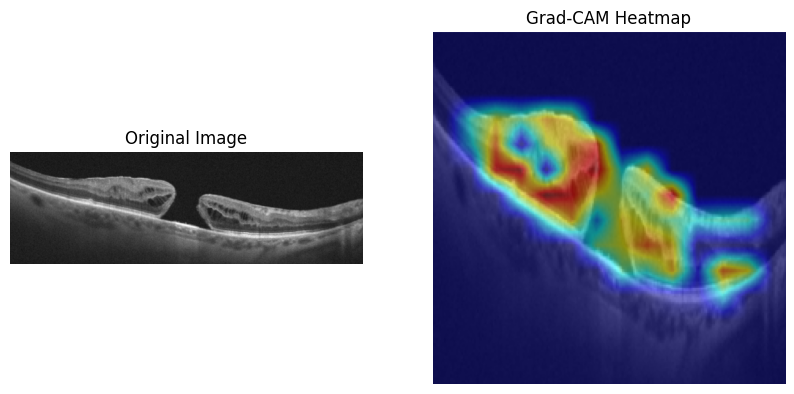

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(original)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Grad-CAM Heatmap")
plt.imshow(cam_img)
plt.axis("off")

plt.show()

In [ ]:
cv2.imwrite("/content/gradcam_output.jpg", cv2.cvtColor(cam_img, cv2.COLOR_RGB2BGR))

from google.colab import files
files.download("/content/gradcam_output.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>